# 9 WorkFlow Analista Jr, futuro=JULIO

### 9.1 Objetivo

Presentar un workflow/pipeline completo al que los estudiantes deberán
<br>El Analista Jr corre sus scripts en la virtual manchine **desktop-jr** que tiene estas características


*   Normal, paga tarifa completa, nunca es apagada por Google
*   reside en el datacenter de Toronto, Canada
*   64 GB de memoria RAM
*   8 vCPU



## 9.3  Workflow

## Inicializacion

Esta parte se debe correr con el runtime en lenguaje **R** Ir al menu, Runtime -> Change Runtime Type -> Runtime type -> R

limpio el ambiente de R

In [1]:
format(Sys.time(), "%a %b %d %X %Y")

[1] "Mon Sep 14 19:53:43 2026"

In [2]:
# limpio la memoria
rm(list=ls(all.names=TRUE)) # remove all objects
gc(full=TRUE, verbose=FALSE) # garbage collection

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,671197,35.9,1479537,79.1,1479537,79.1
Vcells,1242599,9.5,8388608,64.0,1978697,15.1


In [3]:
require("data.table")

if( !require("R.utils")) install.packages("R.utils")
require("R.utils")

Loading required package: data.table


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%


Loading required package: R.utils

Loading required package: R.oo

Loading required package: R.methodsS3

R.methodsS3 v1.8.2 (2022-06-13 22:00:14 UTC) successfully loaded. See ?R.methodsS3 for help.

R.oo v1.27.1 (2025-05-02 21:00:05 UTC) successfully loaded. See ?R.oo for help.


Attaching package: ‘R.oo’


The following object is masked from ‘package:R.methodsS3’:

    throw


The following objects are masked from ‘package:methods’:

    getClasses, getMethods


The following objects are masked from ‘package:base’:

    attach, detach, load, save


R.utils v2.13.0 (2025-02-24 21:20:02 UTC) successfully loaded. See ?R.utils for help.


Attaching package: ‘R.utils’


The following object is masked from ‘package:utils’:

    timestamp


The following objects are masked from ‘package:base’:

    cat, commandArgs, getOption, isOpen, nullfile, parse, u

#### Parametros

In [4]:
set.seed(100129)
sample(100000:999999, 10)

[1] 283558 581941 936130 417893 663577 340263 122994 115483 298558 614281

In [5]:
PARAM <- list()
PARAM$semilla_primigenia <- 100129

PARAM$experimento <- 91118

PARAM$dataset <- "analistajr_competencia_2026.csv.gz"

#### Carpeta del Experimento

In [6]:
# carpeta de trabajo

setwd("/content/buckets/b1/exp")
experimento_folder <- paste0("WF", PARAM$experimento)
dir.create(experimento_folder, showWarnings=FALSE)
setwd( paste0("/content/buckets/b1/exp/", experimento_folder ))

### 9.3.1   Preprocesamiento del dataset

#### 9.3.1.1  DT incorporar dataset

In [7]:
# lectura del dataset
dataset <- fread(paste0("/content/datasets/", PARAM$dataset))

#### 9.3.1.2  CA  Catastrophe Analysis
Se intentan reparar las variables que para un mes están con todos los valores en cero.

El método que se utiliza es **Machine Learning** se asigna NA also valores, si ha leido bien, es la "anti imputación de valores faltantes"
<br> Usted podrá aplicar aquí otros métodos

In [8]:
if( !require("mice")) install.packages("mice", repos = "http://cran.us.r-project.org")
require("mice")

Loading required package: mice


Attaching package: ‘mice’


The following object is masked from ‘package:stats’:

    filter


The following objects are masked from ‘package:base’:

    cbind, rbind




In [9]:
# Escrito por alumnos de  Universidad Austral  Rosario

Corregir_MICE <- function(pcampo, pmeses) {

  meth <- rep("", ncol(dataset))
  names(meth) <- colnames(dataset)
  meth[names(meth) == pcampo] <- "sample"

  # llamada a mice  !
  imputacion <- mice(dataset,
    method = meth,
    maxit = 5,
    m = 1,
    seed = 7)

  tbl <- mice::complete(dataset)

  dataset[, paste0(pcampo) := ifelse(foto_mes %in% pmeses, tbl[, get(pcampo)], get(pcampo))]

}


In [10]:
Corregir_interpolar <- function(pcampo, pmeses) {

  tbl <- dataset[, list(
    "v1" = shift(get(pcampo), 1, type = "lag"),
    "v2" = shift(get(pcampo), 1, type = "lead")
  ),
  by = eval(envg$PARAM$dataset_metadata$entity_id)
  ]

  tbl[, paste0(envg$PARAM$dataset_metadata$entity_id) := NULL]
  tbl[, promedio := rowMeans(tbl, na.rm = TRUE)]

  dataset[
    ,
    paste0(pcampo) := ifelse(!(foto_mes %in% pmeses),
      get(pcampo),
      tbl$promedio
    )
  ]
}

In [11]:
AsignarNA_campomeses <- function(pcampo, pmeses) {

  if( pcampo %in% colnames( dataset ) ) {

    dataset[ foto_mes %in% pmeses, paste0(pcampo) := NA ]
  }
}

In [12]:

Corregir_atributo <- function(pcampo, pmeses, pmetodo)
{
  # si el campo no existe en el dataset, Afuera !
  if( !(pcampo %in% colnames( dataset )) )
    return( 1 )

  # llamo a la funcion especializada que corresponde
  switch( pmetodo,
    "MachineLearning"     = AsignarNA_campomeses(pcampo, pmeses),
    "EstadisticaClasica"  = Corregir_interpolar(pcampo, pmeses),
    "MICE"                = Corregir_MICE(pcampo, pmeses),
  )

  return( 0 )
}

In [13]:

Corregir_Rotas <- function(dataset, pmetodo) {
  gc(verbose= FALSE)
  cat( "inicio Corregir_Rotas()\n")
  # acomodo los errores del dataset

  Corregir_atributo("active_quarter", c(202006), pmetodo) # 1
  Corregir_atributo("internet", c(202006), pmetodo) # 2

  Corregir_atributo("mrentabilidad", c(201905, 201910, 202006), pmetodo) # 3
  Corregir_atributo("mrentabilidad_annual", c(201905, 201910, 202006), pmetodo) # 4

  Corregir_atributo("mcomisiones", c(201905, 201910, 202006), pmetodo) # 5

  Corregir_atributo("mactivos_margen", c(201905, 201910, 202006), pmetodo) # 6
  Corregir_atributo("mpasivos_margen", c(201905, 201910, 202006), pmetodo) # 7

  Corregir_atributo("mcuentas_saldo", c(202006), pmetodo) # 8

  Corregir_atributo("ctarjeta_debito_transacciones", c(202006), pmetodo) # 9

  Corregir_atributo("mautoservicio", c(202006), pmetodo) # 10

  Corregir_atributo("ctarjeta_visa_transacciones", c(202006), pmetodo) # 11
  Corregir_atributo("mtarjeta_visa_consumo", c(202006), pmetodo) # 12

  Corregir_atributo("ctarjeta_master_transacciones", c(202006), pmetodo) # 13
  Corregir_atributo("mtarjeta_master_consumo", c(202006), pmetodo) # 14

  Corregir_atributo("ctarjeta_visa_debitos_automaticos", c(201904), pmetodo) # 15
  Corregir_atributo("mttarjeta_visa_debitos_automaticos", c(201904), pmetodo) # 16

  Corregir_atributo("ccajeros_propios_descuentos",
    c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 17

  Corregir_atributo("mcajeros_propios_descuentos",
    c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 18

  Corregir_atributo("ctarjeta_visa_descuentos",
    c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 19

  Corregir_atributo("mtarjeta_visa_descuentos",
    c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 20

  Corregir_atributo("ctarjeta_master_descuentos",
    c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 21

  Corregir_atributo("mtarjeta_master_descuentos",
    c(201910, 202002, 202006, 202009, 202010, 202102), pmetodo) # 22

  Corregir_atributo("ccomisiones_otras", c(201905, 201910, 202006), pmetodo) # 23
  Corregir_atributo("mcomisiones_otras", c(201905, 201910, 202006), pmetodo) # 24

  Corregir_atributo("cextraccion_autoservicio", c(202006), pmetodo) # 25
  Corregir_atributo("mextraccion_autoservicio", c(202006), pmetodo) # 26

  Corregir_atributo("ccheques_depositados", c(202006), pmetodo) # 27
  Corregir_atributo("mcheques_depositados", c(202006), pmetodo) # 28
  Corregir_atributo("ccheques_emitidos", c(202006), pmetodo) # 29
  Corregir_atributo("mcheques_emitidos", c(202006), pmetodo) # 30
  Corregir_atributo("ccheques_depositados_rechazados", c(202006), pmetodo) # 31
  Corregir_atributo("mcheques_depositados_rechazados", c(202006), pmetodo) # 32
  Corregir_atributo("ccheques_emitidos_rechazados", c(202006), pmetodo) # 33
  Corregir_atributo("mcheques_emitidos_rechazados", c(202006), pmetodo) # 34

  Corregir_atributo("tcallcenter", c(202006), pmetodo) # 35
  Corregir_atributo("ccallcenter_transacciones", c(202006), pmetodo) # 36

  Corregir_atributo("thomebanking", c(202006), pmetodo) # 37
  Corregir_atributo("chomebanking_transacciones", c(201910, 202006), pmetodo) # 38

  Corregir_atributo("ccajas_transacciones", c(202006), pmetodo) # 39
  Corregir_atributo("ccajas_consultas", c(202006), pmetodo) # 40

  Corregir_atributo("ccajas_depositos", c(202006, 202105), pmetodo) # 41

  Corregir_atributo("ccajas_extracciones", c(202006), pmetodo) # 41
  Corregir_atributo("ccajas_otras", c(202006), pmetodo) # 43

  Corregir_atributo("catm_trx", c(202006), pmetodo) # 44
  Corregir_atributo("matm", c(202006), pmetodo) # 45
  Corregir_atributo("catm_trx_other", c(202006), pmetodo) # 46
  Corregir_atributo("matm_other", c(202006), pmetodo) # 47

  cat( "fin Corregir_rotas()\n")
}


In [14]:
# resuelvo el Catastrophe Analysis

setorder( dataset, numero_de_cliente, foto_mes )

PARAM$CA$metodo= "MachineLearning"

if( PARAM$CA$metodo %in% c("MachineLearning", "EstadisticaClasica", "MICE") )
  Corregir_Rotas(dataset, PARAM$CA$metodo)

inicio Corregir_Rotas()
fin Corregir_rotas()


#### 9.3.1.3  DR  Data Drifting
Se intenta corregir el data drifting, ajustando por algunos indices financieros

In [15]:
# meses que me interesan para el ajuste de variables monetarias
vfoto_mes <- c(
  201901, 201902, 201903, 201904, 201905, 201906,
  201907, 201908, 201909, 201910, 201911, 201912,
  202001, 202002, 202003, 202004, 202005, 202006,
  202007, 202008, 202009, 202010, 202011, 202012,
  202101, 202102, 202103, 202104, 202105, 202106,
  202107, 202108, 202109
)


In [16]:
# los valores que siguen fueron calculados por alumnos

# momento 1.0  31-dic-2020 a las 23:59
vIPC <- c(
  1.9903030878, 1.9174403544, 1.8296186587,
  1.7728862972, 1.7212488323, 1.6776304408,
  1.6431248196, 1.5814483345, 1.4947526791,
  1.4484037589, 1.3913580777, 1.3404220402,
  1.3154288912, 1.2921698342, 1.2472681797,
  1.2300475145, 1.2118694724, 1.1881073259,
  1.1693969743, 1.1375456949, 1.1065619600,
  1.0681100000, 1.0370000000, 1.0000000000,
  0.9680542110, 0.9344152616, 0.8882274350,
  0.8532444140, 0.8251880213, 0.8003763543,
  0.7763107219, 0.7566381305, 0.7289384687
)

vdolar_blue <- c(
   39.045455,  38.402500,  41.639474,
   44.274737,  46.095455,  45.063333,
   43.983333,  54.842857,  61.059524,
   65.545455,  66.750000,  72.368421,
   77.477273,  78.191667,  82.434211,
  101.087500, 126.236842, 125.857143,
  130.782609, 133.400000, 137.954545,
  170.619048, 160.400000, 153.052632,
  157.900000, 149.380952, 143.615385,
  146.250000, 153.550000, 162.000000,
  178.478261, 180.878788, 184.357143
)

vdolar_oficial <- c(
   38.430000,  39.428000,  42.542105,
   44.354211,  46.088636,  44.955000,
   43.751429,  54.650476,  58.790000,
   61.403182,  63.012632,  63.011579,
   62.983636,  63.580556,  65.200000,
   67.872000,  70.047895,  72.520952,
   75.324286,  77.488500,  79.430909,
   83.134762,  85.484737,  88.181667,
   91.474000,  93.997778,  96.635909,
   98.526000,  99.613158, 100.619048,
  101.619048, 102.569048, 103.781818
)

vUVA <- c(
  2.001408838932958,  1.950325472789153,  1.89323032351521,
  1.8247220405493787, 1.746027787673673,  1.6871348409529485,
  1.6361678865622313, 1.5927529755859773, 1.5549162794128493,
  1.4949100586391746, 1.4197729500774545, 1.3678188186372326,
  1.3136508617223726, 1.2690535173062818, 1.2381595983200178,
  1.211656735577568,  1.1770808941405335, 1.1570338657445522,
  1.1388769475653255, 1.1156993751209352, 1.093638313080772,
  1.0657171590878205, 1.0362173587708712, 1.0,
  0.9669867858358365, 0.9323750098728378, 0.8958202912590305,
  0.8631993702994263, 0.8253893405524657, 0.7928918905364516,
  0.7666323845128089, 0.7428976357662823, 0.721615762047849
)


In [17]:
tb_indices <- as.data.table( list(
  "IPC" = vIPC,
  "dolar_blue" = vdolar_blue,
  "dolar_oficial" = vdolar_oficial,
  "UVA" = vUVA
  )
)

tb_indices[[ 'foto_mes' ]] <- vfoto_mes

tb_indices

IPC,dolar_blue,dolar_oficial,UVA,foto_mes
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1.9903031,39.04545,38.43000,2.0014088,201901
1.9174404,38.40250,39.42800,1.9503255,201902
1.8296187,41.63947,42.54210,1.8932303,201903
1.7728863,44.27474,44.35421,1.8247220,201904
1.7212488,46.09546,46.08864,1.7460278,201905
1.6776304,45.06333,44.95500,1.6871348,201906
1.6431248,43.98333,43.75143,1.6361679,201907
1.5814483,54.84286,54.65048,1.5927530,201908
1.4947527,61.05952,58.79000,1.5549163,201909


In [18]:
drift_UVA <- function(campos_monetarios) {
  cat( "inicio drift_UVA()\n")

  dataset[tb_indices,
    on = c("foto_mes"),
    (campos_monetarios) := .SD * i.UVA,
    .SDcols = campos_monetarios
  ]

  cat( "fin drift_UVA()\n")
}


In [19]:
drift_dolar_oficial <- function(campos_monetarios) {
  cat( "inicio drift_dolar_oficial()\n")

  dataset[tb_indices,
    on = c("foto_mes"),
    (campos_monetarios) := .SD / i.dolar_oficial,
    .SDcols = campos_monetarios
  ]

  cat( "fin drift_dolar_oficial()\n")
}


In [20]:
drift_dolar_blue <- function(campos_monetarios) {
  cat( "inicio drift_dolar_blue()\n")

  dataset[tb_indices,
    on = c("foto_mes"),
    (campos_monetarios) := .SD / i.dolar_blue,
    .SDcols = campos_monetarios
  ]

  cat( "fin drift_dolar_blue()\n")
}


In [21]:
drift_deflacion <- function(campos_monetarios) {
  cat( "inicio drift_deflacion()\n")

  dataset[tb_indices,
    on = c("foto_mes"),
    (campos_monetarios) := .SD * i.IPC,
    .SDcols = campos_monetarios
  ]

  cat( "fin drift_deflacion()\n")
}


In [22]:
drift_rank_simple <- function(campos_drift) {

  cat( "inicio drift_rank_simple()\n")
  for (campo in campos_drift)
  {
    cat(campo, " ")
    dataset[, paste0(campo, "_rank") :=
      (frank(get(campo), ties.method = "random") - 1) / (.N - 1), by = list(foto_mes)]
    dataset[, (campo) := NULL]
  }
  cat( "fin drift_rank_simple()\n")
}


In [23]:
# El cero se transforma en cero
# los positivos se rankean por su lado
# los negativos se rankean por su lado

drift_rank_cero_fijo <- function(campos_drift) {

  cat( "inicio drift_rank_cero_fijo()\n")
  for (campo in campos_drift)
  {
    cat(campo, " ")
    dataset[get(campo) == 0, paste0(campo, "_rank") := 0]
    dataset[get(campo) > 0, paste0(campo, "_rank") :=
      frank(get(campo), ties.method = "random") / .N, by = list(foto_mes)]

    dataset[get(campo) < 0, paste0(campo, "_rank") :=
      -frank(-get(campo), ties.method = "random") / .N, by = list(foto_mes)]
    dataset[, (campo) := NULL]
  }
  cat("\n")
  cat( "fin drift_rank_cero_fijo()\n")
}


In [24]:
drift_estandarizar <- function(campos_drift) {

  cat( "inicio drift_estandarizar()\n")
  for (campo in campos_drift)
  {
    cat(campo, " ")
    dataset[, paste0(campo, "_normal") :=
      (get(campo) -mean(campo, na.rm=TRUE)) / sd(get(campo), na.rm=TRUE),
      by = list(foto_mes)]

    dataset[, (campo) := NULL]
  }
  cat( "fin drift_estandarizar()\n")
}


In [25]:
# por como armé los nombres de campos,
#  estos son los campos que expresan variables monetarias
campos_monetarios <- colnames(dataset)
campos_monetarios <- campos_monetarios[campos_monetarios %like%
  "^(m|Visa_m|Master_m|vm_m)"]

campos_monetarios

[1] "mrentabilidad"                      "mrentabilidad_annual"              
 [3] "mcomisiones"                        "mactivos_margen"                   
 [5] "mpasivos_margen"                    "mcuenta_corriente"                 
 [7] "mcaja_ahorro"                       "mcuentas_saldo"                    
 [9] "mtarjeta_visa_consumo"              "mtarjeta_master_consumo"           
[11] "mprestamos_personales"              "mpayroll"                          
[13] "mttarjeta_visa_debitos_automaticos" "mcomisiones_mantenimiento"         
[15] "mtransferencias_recibidas"          "Master_mfinanciacion_limite"       
[17] "Master_msaldototal"                 "Master_mlimitecompra"              
[19] "Master_mconsumototal"               "Master_mpagominimo"                
[21] "Visa_mfinanciacion_limite"          "Visa_msaldototal"                  
[23] "Visa_mlimitecompra"                 "Visa_mconsumototal"                
[25] "Visa_mpagominimo"

In [26]:
# ejecuto el Data Drifting
setorder( dataset, numero_de_cliente, foto_mes )


PARAM$DR$metodo <- "deflacion"

switch(PARAM$DR$metodo,
  "ninguno"        = cat("No hay correccion del data drifting"),
  "rank_simple"    = drift_rank_simple(campos_monetarios),
  "rank_cero_fijo" = drift_rank_cero_fijo(campos_monetarios),
  "deflacion"      = drift_deflacion(campos_monetarios),
  "dolar_blue"     = drift_dolarblue(campos_monetarios),
  "dolar_oficial"  = drift_dolaroficial(campos_monetarios),
  "UVA"            = drift_UVA(campos_monetarios),
  "estandarizar"   = drift_estandarizar(campos_monetarios)
)


inicio drift_deflacion()
fin drift_deflacion()


In [27]:
colnames(dataset)

[1] "numero_de_cliente"                  "foto_mes"                          
 [3] "internet"                           "cliente_edad"                      
 [5] "cliente_antiguedad"                 "mrentabilidad"                     
 [7] "mrentabilidad_annual"               "mcomisiones"                       
 [9] "mactivos_margen"                    "mpasivos_margen"                   
[11] "cproductos"                         "mcuenta_corriente"                 
[13] "mcaja_ahorro"                       "cdescubierto_preacordado"          
[15] "mcuentas_saldo"                     "ctarjeta_visa"                     
[17] "ctarjeta_visa_transacciones"        "mtarjeta_visa_consumo"             
[19] "ctarjeta_master"                    "ctarjeta_master_transacciones"     
[21] "mtarjeta_master_consumo"            "cprestamos_personales"             
[23] "mprestamos_personales"              "cpayroll_trx"                      
[25] "mpayroll"                           "mttarjeta_visa_debitos_automaticos"
[27] "ccomisiones_mantenimiento"          "mcomisiones_mantenimiento"         
[29] "ccomisiones_otras"                  "mtransferencias_recibidas"         
[31] "ccallcenter_transacciones"          "thomebanking"                      
[33] "chomebanking_transacciones"         "ctrx_quarter"                      
[35] "Master_status"                      "Master_mfinanciacion_limite"       
[37] "Master_Fvencimiento"                "Master_msaldototal"                
[39] "Master_mlimitecompra"               "Master_fultimo_cierre"             
[41] "Master_fechaalta"                   "Master_mconsumototal"              
[43] "Master_cconsumos"                   "Master_mpagominimo"                
[45] "Visa_status"                        "Visa_mfinanciacion_limite"         
[47] "Visa_Fvencimiento"                  "Visa_msaldototal"                  
[49] "Visa_mlimitecompra"                 "Visa_fultimo_cierre"               
[51] "Visa_fechaalta"                     "Visa_mconsumototal"                
[53] "Visa_cconsumos"                     "Visa_mpagominimo"                  
[55] "clase_ternaria"

In [28]:
# se intenta corregir el data drifting utilizando algunos indices financieros

#### 9.3.1.3  FE_intra_manual Feature Engineering intra-mes

Agrego campos nuevos dentro del mismo mes, SIN considerar la historia.

In [29]:
# esta funcion atributos presentes existe debido a que las modalidades poseen datasets con distinta cantidad de campos
atributos_presentes <- function( patributos )
{
  atributos <- unique( patributos )
  comun <- intersect( atributos, colnames(dataset) )

  return(  length( atributos ) == length( comun ) )
}

# el mes 1,2, ..12
if( atributos_presentes( c("foto_mes") ))
  dataset[, kmes := foto_mes %% 100]

# variable extraida de una tesis de maestria de Irlanda
if( atributos_presentes( c("mpayroll", "cliente_edad") ))
  dataset[, mpayroll_sobre_edad := mpayroll / cliente_edad]


In [30]:
#### 9.3.1.3 (continuación)  FE_intra_GA  Feature Engineering intra-mes con Algoritmo Genético
# Generación automática de nuevas variables intra-mes

library(lightgbm)

# --- valores propios de este bloque, sin depender de PARAM$trainingstrategy ---
# (esa sección se define más adelante, en 9.3.2; se duplica acá para no tocarla)
meses_training_ga <- c(
  201901, 201902, 201903, 201904, 201905, 201906,
  201907, 201908, 201909, 201910, 201911, 201912,
  202001, 202002, 202003, 202004, 202005, 202006,
  202007, 202008, 202009, 202010, 202011, 202012,
  202101, 202102, 202103
)
positivos_ga <- c("BAJA+1", "BAJA+2")

# columnas numéricas candidatas para combinaciones
cols_candidatas <- c(
  "cliente_edad", "cliente_antiguedad", "mrentabilidad", "mrentabilidad_annual",
  "mcomisiones", "mactivos_margen", "mpasivos_margen", "mcuenta_corriente",
  "mcaja_ahorro", "mcuentas_saldo", "mtarjeta_visa_consumo", "mtarjeta_master_consumo",
  "mprestamos_personales", "mpayroll", "mcomisiones_mantenimiento",
  "mtransferencias_recibidas", "Master_msaldototal", "Master_mlimitecompra",
  "Master_mconsumototal", "Master_mpagominimo", "Visa_msaldototal",
  "Visa_mlimitecompra", "Visa_mconsumototal", "Visa_mpagominimo"
)

# operaciones permitidas
operaciones <- c("ratio", "producto", "suma", "resta")

# función para crear variable combinada
crear_variable <- function(dataset, var1, var2, operacion) {
  nombre <- paste0("GA_", var1, "_", operacion, "_", var2)

  if (operacion == "ratio")     dataset[, (nombre) := get(var1) / (get(var2) + 1)]
  if (operacion == "producto")  dataset[, (nombre) := get(var1) * get(var2)]
  if (operacion == "suma")      dataset[, (nombre) := get(var1) + get(var2)]
  if (operacion == "resta")     dataset[, (nombre) := get(var1) - get(var2)]

  return(nombre)
}

# función de aptitud usando LightGBM
# SOLO sobre meses de training (evita fuga de datos hacia validate/future)
fitness_variable <- function(dataset, nueva_var) {
  filas_train <- dataset[, foto_mes %in% meses_training_ga]

  dtrain <- lgb.Dataset(
    data  = as.matrix(dataset[filas_train, nueva_var, with = FALSE]),
    label = as.numeric(dataset[filas_train, clase_ternaria] %in% positivos_ga)
  )

  modelo <- lgb.train(
    params  = list(objective = "binary", metric = "auc"),
    data    = dtrain,
    nrounds = 50,
    verbose = -1
  )

  return(modelo$best_score)
}

# generación inicial de población
generar_poblacion <- function(n = 20) {
  poblacion <- list()
  for (i in 1:n) {
    var1 <- sample(cols_candidatas, 1)
    var2 <- sample(cols_candidatas, 1)
    op   <- sample(operaciones, 1)
    poblacion[[i]] <- list(var1 = var1, var2 = var2, op = op)
  }
  return(poblacion)
}

# evaluación de población — crea, mide, y borra la columna temporal
# (si no se borra, FE histórico le genera lag/delta a cada intento descartado)
evaluar_poblacion <- function(dataset, poblacion) {
  resultados <- list()
  for (i in seq_along(poblacion)) {
    ind <- poblacion[[i]]
    nueva_var <- crear_variable(dataset, ind$var1, ind$var2, ind$op)
    aptitud   <- fitness_variable(dataset, nueva_var)
    dataset[, (nueva_var) := NULL]   # limpieza inmediata

    resultados[[i]] <- list(individuo = ind, aptitud = aptitud)
  }
  return(resultados)
}

# selección de elite
seleccion <- function(resultados, k = 10) {
  ordenados <- resultados[order(sapply(resultados, function(x) x$aptitud), decreasing = TRUE)]
  return(ordenados[1:k])
}

# cruce
cruce <- function(ind1, ind2) {
  list(var1 = ind1$var1, var2 = ind2$var2, op = sample(operaciones, 1))
}

# mutación
mutacion <- function(ind) {
  if (runif(1) < 0.3) ind$var1 <- sample(cols_candidatas, 1)
  if (runif(1) < 0.3) ind$var2 <- sample(cols_candidatas, 1)
  if (runif(1) < 0.3) ind$op   <- sample(operaciones, 1)
  return(ind)
}

# ciclo evolutivo completo
ejecutar_GA <- function(dataset, generaciones = 5, tam_poblacion = 20) {
  poblacion <- generar_poblacion(tam_poblacion)

  for (g in 1:generaciones) {
    resultados <- evaluar_poblacion(dataset, poblacion)
    elite <- seleccion(resultados, k = 10)

    nueva_poblacion <- list()
    for (i in 1:10) nueva_poblacion[[i]] <- elite[[i]]$individuo

    for (i in 11:tam_poblacion) {
      padres <- sample(elite, 2)
      hijo <- cruce(padres[[1]]$individuo, padres[[2]]$individuo)
      hijo <- mutacion(hijo)
      nueva_poblacion[[i]] <- hijo
    }
    poblacion <- nueva_poblacion
  }

  resultados_finales <- evaluar_poblacion(dataset, poblacion)
  elite_final <- seleccion(resultados_finales, k = 5)
  return(elite_final)
}

# --- ejecución, con semilla fija para reproducibilidad ---
# misma semilla que el resto del experimento, seteada ANTES de cualquier sample()/runif()
# de este bloque, porque el set.seed del notebook original (sección 9.3.2) corre después
set.seed(PARAM$semilla_primigenia)

elite <- ejecutar_GA(dataset, generaciones = 5, tam_poblacion = 20)

# agregar SOLO las variables ganadoras al dataset
for (e in elite) {
  ind <- e$individuo
  crear_variable(dataset, ind$var1, ind$var2, ind$op)
}



In [31]:
# visualizo las columas del dataset a esta etapa
colnames(dataset)

[1] "numero_de_cliente"                                 
 [2] "foto_mes"                                          
 [3] "internet"                                          
 [4] "cliente_edad"                                      
 [5] "cliente_antiguedad"                                
 [6] "mrentabilidad"                                     
 [7] "mrentabilidad_annual"                              
 [8] "mcomisiones"                                       
 [9] "mactivos_margen"                                   
[10] "mpasivos_margen"                                   
[11] "cproductos"                                        
[12] "mcuenta_corriente"                                 
[13] "mcaja_ahorro"                                      
[14] "cdescubierto_preacordado"                          
[15] "mcuentas_saldo"                                    
[16] "ctarjeta_visa"                                     
[17] "ctarjeta_visa_transacciones"                       
[18] "mtarjeta_visa_consumo"                             
[19] "ctarjeta_master"                                   
[20] "ctarjeta_master_transacciones"                     
[21] "mtarjeta_master_consumo"                           
[22] "cprestamos_personales"                             
[23] "mprestamos_personales"                             
[24] "cpayroll_trx"                                      
[25] "mpayroll"                                          
[26] "mttarjeta_visa_debitos_automaticos"                
[27] "ccomisiones_mantenimiento"                         
[28] "mcomisiones_mantenimiento"                         
[29] "ccomisiones_otras"                                 
[30] "mtransferencias_recibidas"                         
[31] "ccallcenter_transacciones"                         
[32] "thomebanking"                                      
[33] "chomebanking_transacciones"                        
[34] "ctrx_quarter"                                      
[35] "Master_status"                                     
[36] "Master_mfinanciacion_limite"                       
[37] "Master_Fvencimiento"                               
[38] "Master_msaldototal"                                
[39] "Master_mlimitecompra"                              
[40] "Master_fultimo_cierre"                             
[41] "Master_fechaalta"                                  
[42] "Master_mconsumototal"                              
[43] "Master_cconsumos"                                  
[44] "Master_mpagominimo"                                
[45] "Visa_status"                                       
[46] "Visa_mfinanciacion_limite"                         
[47] "Visa_Fvencimiento"                                 
[48] "Visa_msaldototal"                                  
[49] "Visa_mlimitecompra"                                
[50] "Visa_fultimo_cierre"                               
[51] "Visa_fechaalta"                                    
[52] "Visa_mconsumototal"                                
[53] "Visa_cconsumos"                                    
[54] "Visa_mpagominimo"                                  
[55] "clase_ternaria"                                    
[56] "kmes"                                              
[57] "mpayroll_sobre_edad"                               
[58] "GA_mrentabilidad_resta_mpasivos_margen"            
[59] "GA_Visa_mlimitecompra_ratio_mrentabilidad"         
[60] "GA_mactivos_margen_resta_Master_mpagominimo"       
[61] "GA_Master_msaldototal_ratio_Master_mconsumototal"  
[62] "GA_mrentabilidad_annual_producto_mcuenta_corriente"

In [32]:
saveRDS(elite, file = "elite_GA.rds")
cat("GA terminado -", format(Sys.time(), "%X"), "- variables:",
    paste(sapply(elite, function(e) paste0("GA_", e$individuo$var1, "_", e$individuo$op, "_", e$individuo$var2)), collapse = ", "),
    "\n", file = "log_GA.txt", append = TRUE)

#### 9.3.1.4  FE_rf Feature Engineering de nuevas variables a partir de hojas de Random Forest

In [33]:
# No se implementa Feature Engineering a partir de Random Forest

#### 9.3.1.5  FEhist Feature Engineering historico

El Fature Engineering Histórico es la etapa que más aporta a la ganancia final, ya que enriquece cada registro del dataset con su historia.

Para cada campo del dataset original (*)
se crean lo siguientes campos de a partir de la historia
* lag1  lags de orden 1
* delta1  =  valor actual - lag1
* lag2  lags de orden 2
* delta2  = valor actual - lag2


(*) Excepto para los campos  <numero_de_cliente,  foto_mes,  clase_ternaria>

In [34]:
# Feature Engineering Historico

# todo es lagueable, menos la primary key y la clase
cols_lagueables <- copy( setdiff(
    colnames(dataset),
    c("numero_de_cliente", "foto_mes", "clase_ternaria")
) )

# https://rdrr.io/cran/data.table/man/shift.html

# lags de orden 1
dataset[,
    paste0(cols_lagueables, "_lag1") := shift(.SD, 1, NA, "lag"),
    by = numero_de_cliente,
    .SDcols = cols_lagueables
]

# lags de orden 2
dataset[,
    paste0(cols_lagueables, "_lag2") := shift(.SD, 2, NA, "lag"),
    by = numero_de_cliente,
    .SDcols = cols_lagueables
]

# agrego los delta lags
for (vcol in cols_lagueables)
{
    dataset[, paste0(vcol, "_delta1") := get(vcol) - get(paste0(vcol, "_lag1"))]
    dataset[, paste0(vcol, "_delta2") := get(vcol) - get(paste0(vcol, "_lag2"))]
}


Verificacion de los campos recien creados

In [35]:
ncol(dataset)
colnames(dataset)

[1] 298

[1] "numero_de_cliente"                                        
  [2] "foto_mes"                                                 
  [3] "internet"                                                 
  [4] "cliente_edad"                                             
  [5] "cliente_antiguedad"                                       
  [6] "mrentabilidad"                                            
  [7] "mrentabilidad_annual"                                     
  [8] "mcomisiones"                                              
  [9] "mactivos_margen"                                          
 [10] "mpasivos_margen"                                          
 [11] "cproductos"                                               
 [12] "mcuenta_corriente"                                        
 [13] "mcaja_ahorro"                                             
 [14] "cdescubierto_preacordado"                                 
 [15] "mcuentas_saldo"                                           
 [16] "ctarjeta_visa"                                            
 [17] "ctarjeta_visa_transacciones"                              
 [18] "mtarjeta_visa_consumo"                                    
 [19] "ctarjeta_master"                                          
 [20] "ctarjeta_master_transacciones"                            
 [21] "mtarjeta_master_consumo"                                  
 [22] "cprestamos_personales"                                    
 [23] "mprestamos_personales"                                    
 [24] "cpayroll_trx"                                             
 [25] "mpayroll"                                                 
 [26] "mttarjeta_visa_debitos_automaticos"                       
 [27] "ccomisiones_mantenimiento"                                
 [28] "mcomisiones_mantenimiento"                                
 [29] "ccomisiones_otras"                                        
 [30] "mtransferencias_recibidas"                                
 [31] "ccallcenter_transacciones"                                
 [32] "thomebanking"                                             
 [33] "chomebanking_transacciones"                               
 [34] "ctrx_quarter"                                             
 [35] "Master_status"                                            
 [36] "Master_mfinanciacion_limite"                              
 [37] "Master_Fvencimiento"                                      
 [38] "Master_msaldototal"                                       
 [39] "Master_mlimitecompra"                                     
 [40] "Master_fultimo_cierre"                                    
 [41] "Master_fechaalta"                                         
 [42] "Master_mconsumototal"                                     
 [43] "Master_cconsumos"                                         
 [44] "Master_mpagominimo"                                       
 [45] "Visa_status"                                              
 [46] "Visa_mfinanciacion_limite"                                
 [47] "Visa_Fvencimiento"                                        
 [48] "Visa_msaldototal"                                         
 [49] "Visa_mlimitecompra"                                       
 [50] "Visa_fultimo_cierre"                                      
 [51] "Visa_fechaalta"                                           
 [52] "Visa_mconsumototal"                                       
 [53] "Visa_cconsumos"                                           
 [54] "Visa_mpagominimo"                                         
 [55] "clase_ternaria"                                           
 [56] "kmes"                                                     
 [57] "mpayroll_sobre_edad"                                      
 [58] "GA_mrentabilidad_resta_mpasivos_margen"                   
 [59] "GA_Visa_mlimitecompra_ratio_mrentabilidad"                
 [60] "GA_mactivos_margen_resta_Master_mpagominimo"              
 [61] "GA_Master_msaldototal_ratio_Master_

#### 9.3.1.6  FEhist Reduccion dimensionalidad con canaritos

Esta etapa solo se mostrará a la *modalidad Anlista Sr* por algun canal secreto de forma de no confundir a los *Analista Jr*  ni distraer con detalles operativos a la estratégica *Modalidad Gerencial*

In [36]:
# No se implementa la reduccion de la dimensionalidad con canaritos

### 9.3.2 Modelado

#### 9.3.2.1 Training Strategy

Se hace una estrategia de entrenamiento muy sencilla, tomando todos los meses posibles, SIN eliminar nada x pandemia ni por ningun otro motivo

* future = 202109  obviamente completo

* final_train =  [ 201901, 202107 ]  SIN undersampling

* training
   * testing = NO HAY
   * validation =  202105   completo, sin undersampling
   * training = [ 201901, 202103 ]  donde se consideran el 100% de los CONTINUA

In [37]:
PARAM$trainingstrategy$validate <- c(202105)

PARAM$trainingstrategy$training <- c(
  201901, 201902, 201903, 201904, 201905, 201906,
  201907, 201908, 201909, 201910, 201911, 201912,
  202001, 202002, 202003, 202004, 202005, 202006,
  202007, 202008, 202009, 202010, 202011, 202012,
  202101, 202102, 202103
)


PARAM$trainingstrategy$training_pct <- 1.0


PARAM$trainingstrategy$positivos <- c( "BAJA+1", "BAJA+2")

In [38]:
# seteo la clase01   1={BAJA+1, BAJA+2}   0={CONTINUA}
dataset[, clase01 := ifelse( clase_ternaria %in% PARAM$trainingstrategy$positivos, 1, 0 )]

In [39]:
# los campos en los que se entrena
campos_buenos <- copy( setdiff(
    colnames(dataset), c("clase_ternaria","clase01","azar"))
)

In [40]:
# preparo para que se puede hacer undersampling de los CONTINUA
#  solamente por un tema de VELOCIDAD
set.seed(PARAM$semilla_primigenia, kind = "L'Ecuyer-CMRG")
dataset[, azar:=runif(nrow(dataset))]

# undersampling de los CONTINUA
dataset[, fold_train :=  foto_mes %in%  PARAM$trainingstrategy$training &
    (clase_ternaria %in% c("BAJA+1", "BAJA+2") |
     azar < PARAM$trainingstrategy$training_pct ) ]


if( !require("lightgbm")) install.packages("lightgbm")
require("lightgbm")

dtrain <- lgb.Dataset(
  data= data.matrix(dataset[fold_train == TRUE, campos_buenos, with = FALSE]),
  label= dataset[fold_train == TRUE, clase01],
  free_raw_data= TRUE
)

In [41]:
# datos de validation
dvalidate <- lgb.Dataset(
  data= data.matrix(dataset[foto_mes %in% PARAM$trainingstrategy$validate, campos_buenos, with = FALSE]),
  label= dataset[foto_mes %in% PARAM$trainingstrategy$validate, clase01],
  free_raw_data= TRUE
)

nrow(dvalidate)

[1] 32787

####  9.3.2.2. Hyperparameter Tuning

* Clase binaria que se optimiza :  positivos = [ BAJA+1, BAJA+2 ]

* Metrica que se optimiza **AUC** Area Under Curve de la  ROC Curve

es muy importante notar que intencionalmente  **NO** se está optimizando la funcion de ganancia del problema

* Parametros no default, fijos de LightGBM que no se optimizan
  * max_bin = 31 , Alienigenas Ancestrales contruyeron las pirámides y dejaron a la humanidad en un jeroglifico  *max_bin=31*
  * feature_fraction = 0.5  para poner algo que generalmente no falla
  * learning_rate = 0.03  para que aprenda lento


* Parametros que se optimizan en el Grid Search
  * num_leaves  [64, 512]
  * min_data_in_leaf  [64, 2048]

In [42]:
# parametros fijos del LightGBM
PARAM$lgbm$param_fijos <- list(
  objective= "binary",
  metric= "auc",
  first_metric_only= TRUE,
  boost_from_average= TRUE,
  feature_pre_filter= FALSE,
  verbosity= -100,
  force_row_wise= TRUE, # para evitar warning
  seed= PARAM$semilla_primigenia,
  max_bin= 31,
  learning_rate= 0.03,
  feature_fraction= 0.5,
  num_iterations= 2048,  # valor grande, lo limita early_stopping_rounds
  early_stopping_rounds= 200,
  num_leaves= 64,
  min_data_in_leaf= 128
)


In [43]:
# En  x llegan los parametros moviles de LightGBM
#  devuelve la AUC en validate del modelo entrenado
#  en el parametro x llegan los hiperparámetros que se estan optimizando

Estimar_AUC_lightgbm <- function(x) {

  # x pisa (o agrega) a param_fijos
  param_completo <- modifyList(PARAM$lgbm$param_fijos, x)

  # entreno LightGBM
  modelo_train <- lgb.train(
    data= dtrain,
    valids= list(valid = dvalidate),
    eval= "auc",
    param= param_completo,
    verbose= -100
  )

  # recupero la AUC en validation
  AUC <- modelo_train$record_evals$valid$auc$eval[[modelo_train$best_iter]]

  message(format(Sys.time(), "%a %b %d %X %Y  "),
    toString(x),
    " niter ", modelo_train$best_iter,
    " AUC ", AUC
  )

  # hago espacio en la memoria
  niter <- modelo_train$best_iter
  rm(modelo_train)
  gc(full= TRUE, verbose= FALSE)

  return( list(AUC, niter))
}

seteo del Grid Search

In [44]:
# lo que sigue a continuacion es una forma alternativa a los loops anidados
# creo una tabla con el producto cartesiano de los vectores
tb_nueva <- CJ(
  num_leaves= c(64, 128, 256, 384, 512),
  min_data_in_leaf= c(64, 256, 512, 1024, 2048),
  feature_fraction= c(0.5, 0.8)
)

Corrida del Grid Search,  aqui se hace el trabajo pesado
<br> por favor no se asuste con los warnings que pudieran aparecer
<br> ATENCION, la siguiente celda demora 60 minutos en Colab
<br> lamento profundamente tal intolerable espera gerencial

In [45]:
# registro a registro calculo la AUC
tb_nueva[,  c("AUC", "num_iterations"):= Estimar_AUC_lightgbm( .SD ),
  by=1:nrow(tb_nueva) ]

Mon Sep 14 19:57:19 2026  64, 64, 0.5 niter 343 AUC 0.929385494943071

Mon Sep 14 19:58:02 2026  64, 64, 0.8 niter 367 AUC 0.929692397976153

Mon Sep 14 19:59:10 2026  64, 256, 0.5 niter 275 AUC 0.928988683262705

Mon Sep 14 19:59:47 2026  64, 256, 0.8 niter 263 AUC 0.928823421874724

Mon Sep 14 20:00:55 2026  64, 512, 0.5 niter 272 AUC 0.932577578373379

Mon Sep 14 20:01:31 2026  64, 512, 0.8 niter 217 AUC 0.929648615038133

Mon Sep 14 20:02:42 2026  64, 1024, 0.5 niter 287 AUC 0.93247472687512

Mon Sep 14 20:03:20 2026  64, 1024, 0.8 niter 243 AUC 0.930743879798168

Mon Sep 14 20:04:49 2026  64, 2048, 0.5 niter 402 AUC 0.932025644511732

Mon Sep 14 20:05:34 2026  64, 2048, 0.8 niter 288 AUC 0.931788026057761

Mon Sep 14 20:06:50 2026  128, 64, 0.5 niter 293 AUC 0.928935990112737

Mon Sep 14 20:07:33 2026  128, 64, 0.8 niter 257 AUC 0.928395347640368

Mon Sep 14 20:08:34 2026  128, 256, 0.5 niter 220 AUC 0.929612628535568

Mon Sep 14 20:09:17 2026  128, 256, 0.8 niter 188 AUC 0.930260

la optimizacion de hiperparámetros de tipo  Grid Search ha corrido, extraigo los mejores hiperparametros

In [46]:
tb_nueva

fwrite( tb_nueva,
  file= "tb_grid_search_01.txt",
  sep="\t",
  append= TRUE
)

num_leaves,min_data_in_leaf,feature_fraction,AUC,num_iterations
<dbl>,<dbl>,<dbl>,<dbl>,<int>
64,64,0.5,0.9293855,343
64,64,0.8,0.9296924,367
64,256,0.5,0.9289887,275
64,256,0.8,0.9288234,263
64,512,0.5,0.9325776,272
64,512,0.8,0.9296486,217
64,1024,0.5,0.9324747,287
64,1024,0.8,0.9307439,243
64,2048,0.5,0.9320256,402


In [47]:
setorder( tb_nueva, -AUC)  # ordeno DESCENDENTE por AUC
PARAM$out$lgbm$AUC <- tb_nueva[1, AUC] # en la posicion 1 estan los mejores
PARAM$out$lgbm$mejores_hiperparametros <- as.list( tb_nueva[1] )
PARAM$out$lgbm$mejores_hiperparametros$AUC <- NULL
PARAM$out$lgbm$mejores_hiperparametros

$num_leaves
[1] 64

$min_data_in_leaf
[1] 512

$feature_fraction
[1] 0.5

$num_iterations
[1] 272

### 9.3.3 Produccion

#### Final Training
Construyo el modelo final, que es uno solo, no hace ningun tipo de particion < training, validation, testing>]

##### Final Training Dataset

Aqui esta la gran decision de en qué meses hago el Final Training
<br> debo utilizar los mejores hiperparámetros que encontré en la optimización bayesiana

In [48]:
PARAM$trainingstrategy$final_train <- c(
  201901, 201902, 201903, 201904, 201905, 201906,
  201907, 201908, 201909, 201910, 201911, 201912,
  202001, 202002, 202003, 202004, 202005, 202006,
  202007, 202008, 202009, 202010, 202011, 202012,
  202101, 202102, 202103, 202104, 202105
)


dataset[, fold_final_train := foto_mes %in% PARAM$trainingstrategy$final_train ]

# creo el dfinal_train en formato  LightGBM
dfinal_train <- lgb.Dataset(
  data= data.matrix(dataset[fold_final_train == TRUE, campos_buenos, with= FALSE]),
  label= dataset[fold_final_train == TRUE, clase01],
  free_raw_data= TRUE
)

nrow( dfinal_train) # verifico el tamaño

[1] 845024

##### Final Training Hyperparameters

In [49]:
# uno los parametros fijos y los mejores encontrados de los variables
fijos <- copy(PARAM$lgbm$param_fijos)

# quito lo que optimice en la Bayesian Optimization
fijos$num_iterations <- NULL
fijos$early_stopping_rounds <- NULL

# agrego a los hiperparametros fijos los que encontre con la Bayesian Optimization
param_final <- c(fijos, PARAM$out$lgbm$mejores_hiperparametros)

##### Training
Genero el modelo final, siempre sobre TODOS los datos de  final_train, sin hacer ningun tipo de undersampling de la clase mayoritaria

In [50]:
final_model <- lgb.train(
  data= dfinal_train,
  param= param_final,
  verbose= -100
)

In [51]:
# grabo a disco el modelo en un formato para seres humanos ... ponele ...

lgb.save(final_model, "modelo.txt")

In [52]:
# ahora imprimo la importancia de variables

tb_importancia <- as.data.table(lgb.importance(final_model))
archivo_importancia <- "impo.txt"

fwrite( tb_importancia,
  file= archivo_importancia,
  sep= "\t"
)

#### Scoring

Aplico el modelo final a los datos del futuro

In [53]:
PARAM$trainingstrategy$future <- c(202107)

dfuture <- dataset[ foto_mes %in% PARAM$trainingstrategy$future ]

In [54]:
# aplico final_model   a dfuture

prediccion <- predict(
  final_model,
  data.matrix(dfuture[, campos_buenos, with= FALSE])
)

##### Tabla Prediccion

In [55]:
tb_prediccion <- dfuture[, list(numero_de_cliente, clase_ternaria)]
tb_prediccion[, prob := prediccion]

# grabo las probabilidad del modelo
#  me va a ser util para hacer Ensembles de modelos
fwrite(tb_prediccion,
  file= "prediccion.txt",
  sep= "\t"
)

#### Curva de Ganancia

Genero las salidas

In [56]:
# asigno clase ternaria
tb_prediccion[, clase_ternaria := dfuture$clase_ternaria ]

# asigno ganancias
tb_prediccion[, ganancia := -0.025 ]
tb_prediccion[clase_ternaria=="BAJA+2", ganancia := 0.975 ]

# reordeno, y acumulada
setorder( tb_prediccion, -prob )
tb_prediccion[, gan_acum := cumsum(ganancia)]

# media movil de ancho 400
tb_prediccion[,
  gan_suavizada := frollmean(
    x= gan_acum,
    n= 400,
    align= "center",
    na.rm= TRUE,
    hasNA= TRUE
  )
]


Warning message in froll(fun = "mean", x = x, n = n, fill = fill, algo = algo, align = align, :
“hasNA is deprecated, use has.nf instead”


In [57]:
tb_prediccion[, sum(!is.na(gan_suavizada) )]
tb_prediccion[, .N]

[1] 32539

[1] 32938

In [58]:
# Este es la ganancia a reportar
resultado <- list()
resultado$ganancia_suavizada_max <- max( tb_prediccion$gan_suavizada, na.rm=TRUE )
options(digits= 8)
resultado$envios <- which.max( tb_prediccion$gan_suavizada)
resultado

$ganancia_suavizada_max
[1] 93.315

$envios
[1] 2249

In [59]:
# grabo las ganancias
fwrite( tb_prediccion,
  file= "ganancias.txt",
  sep= "\t"
)

In [60]:
# genero el grafico

tb_prediccion[, envios:= .I]

pdf("curva_de_ganancia.pdf")

plot(
  x= tb_prediccion$envios,
  y= tb_prediccion$gan_acum,
  type= "l",
  col= "gray",
  xlim= c(0, 10000),
  ylim= c(0, 15000000),
  main= paste0("Mejor gan prom= ", as.integer(resultado$ganancia_suavizada_max), " envios= ", resultado$envios),
  xlab= "Envios",
  ylab= "Ganancia",
  panel.first= grid()
)

dev.off()

agg_record_132338195314 
                      2

In [61]:
# grabo los parametros
if( !require("yaml")) install.packages("yaml")
require("yaml")

PARAM$resultado <- resultado

write_yaml( PARAM, file="PARAM.yml")

Loading required package: yaml



In [62]:
format(Sys.time(), "%a %b %d %X %Y")

[1] "Mon Sep 14 20:54:09 2026"

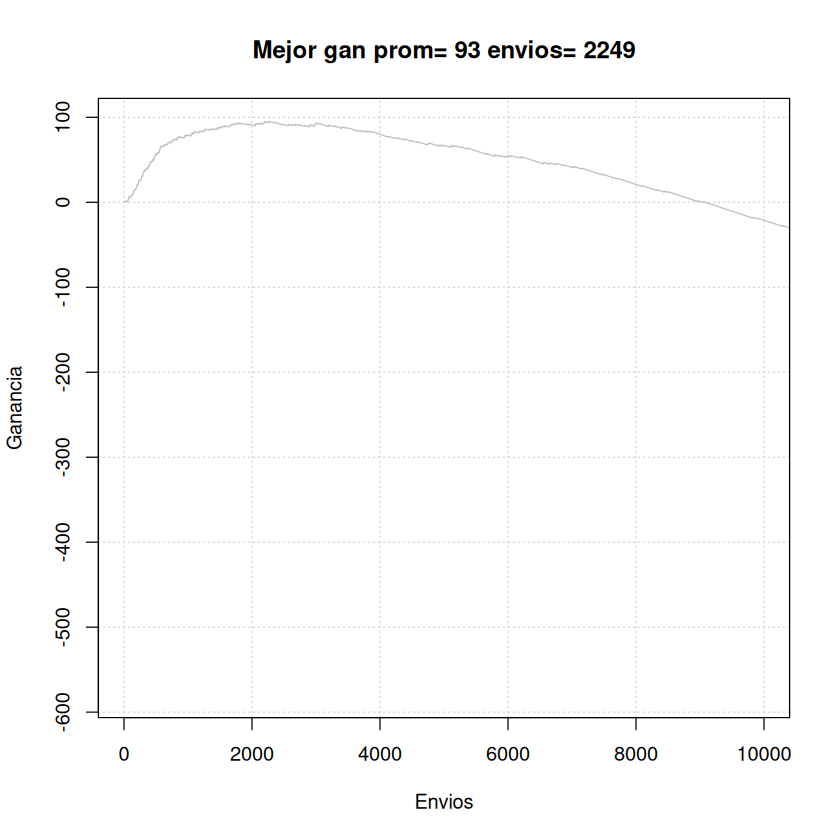

In [63]:
plot(
  tb_prediccion$envios,
  tb_prediccion$gan_acum,
  type="l",
  col="gray",
  xlim=c(0,10000),
  ylim=c(min(tb_prediccion$gan_acum), max(tb_prediccion$gan_acum)),
  main=paste0("Mejor gan prom= ", as.integer(resultado$ganancia_suavizada_max), " envios= ", resultado$envios),
  xlab="Envios",
  ylab="Ganancia",
  panel.first=grid()
)



In [64]:
pdf("curva_de_ganancia_corregida.pdf")

plot(
  tb_prediccion$envios,
  tb_prediccion$gan_acum,
  type="l",
  col="gray",
  xlim=c(0,10000),
  ylim=c(min(tb_prediccion$gan_acum), max(tb_prediccion$gan_acum)),
  main=paste0("Mejor gan prom= ", as.integer(resultado$ganancia_suavizada_max), " envios= ", resultado$envios),
  xlab="Envios",
  ylab="Ganancia",
  panel.first=grid()
)

dev.off()


agg_record_1323ad34198 
                     2

In [65]:
impo <- fread("impo.txt")   # 
impo[Feature %like% "GA_"]

Feature,Gain,Cover,Frequency
<chr>,<dbl>,<dbl>,<dbl>
GA_mactivos_margen_resta_Master_mpagominimo,0.00396441472,0.00886539816,0.0063608777
GA_mrentabilidad_annual_producto_mcuenta_corriente,0.00306539463,0.00420885231,0.0063608777
GA_mrentabilidad_resta_mpasivos_margen,0.00272390130,0.00049120483,0.0034430439
GA_Visa_mlimitecompra_ratio_mrentabilidad,0.00251345421,0.00856418019,0.0068277311
GA_Visa_mlimitecompra_ratio_mrentabilidad_lag1,0.00241909887,0.00161755919,0.0060107376
GA_Visa_mlimitecompra_ratio_mrentabilidad_lag2,0.00214212603,0.00188716997,0.0053688142
GA_mrentabilidad_annual_producto_mcuenta_corriente_lag2,0.00197735020,0.00233070177,0.0042600373
GA_mactivos_margen_resta_Master_mpagominimo_lag2,0.00189746084,0.00375747729,0.0046685341
GA_mrentabilidad_resta_mpasivos_margen_delta2,0.00181948639,0.00038956030,0.0034430439
